In [19]:
# Cell 1 - Install and verify environment
import os
import sys
import json
import time
import math
import shutil
import random
import socket
import pathlib
import platform
import subprocess
from pathlib import Path

REQUIRED_PACKAGES = [
    "torch", "numpy", "pandas", "matplotlib", "psutil", "tqdm", "datasets", "tiktoken"
]

def run_cmd(cmd, check=False, capture=True):
    result = subprocess.run(cmd, shell=True, text=True,
                            stdout=subprocess.PIPE if capture else None,
                            stderr=subprocess.STDOUT if capture else None)
    if check and result.returncode != 0:
        raise RuntimeError(result.stdout)
    return result

missing = []
for package in REQUIRED_PACKAGES:
    import_name = package
    try:
        __import__(import_name)
    except Exception:
        missing.append(package)

if missing:
    print("Installing missing packages:", missing)
    run_cmd(f"{sys.executable} -m pip install -q " + " ".join(missing), check=True, capture=False)

# rclone is needed for VastAI -> Google Drive sync.
if shutil.which("rclone") is None:
    print("rclone not found. Installing rclone...")
    install = run_cmd("curl -fsSL https://rclone.org/install.sh | bash", check=False, capture=True)
    print(install.stdout[-1000:] if install.stdout else "")
else:
    print("rclone found:", shutil.which("rclone"))

print("Python:", sys.version.split()[0])
try:
    gpu = run_cmd("nvidia-smi --query-gpu=name,memory.total --format=csv,noheader", capture=True)
    print("GPU:", gpu.stdout.strip() if gpu.stdout else "No GPU output")
except Exception as exc:
    print("GPU check failed:", exc)

rclone found: /usr/bin/rclone
Python: 3.12.13
GPU: NVIDIA A100-SXM4-40GB, 40960 MiB


In [20]:
# Cell 2 - Main experiment configuration
from dataclasses import dataclass, asdict, field
from typing import Dict, List, Optional, Any

# ── PROJECT IDENTITY ────────────────────────────────────────────────────────
# DIFFERENT from 10M runs — keeps 124M results in a separate GDrive folder.
PROJECT_ID = "residual_124m_corrected_v1"

# 124M model on OpenWebText
MODEL_PRESET    = "124M"
DATASET_PRESET  = "openwebtext_bpe"
RUN_PLAN        = "core_baselines_small"

# ── PATHS ────────────────────────────────────────────────────────────────────
# /workspace is persistent on Vast.ai while the instance exists.
LOCAL_ROOT  = Path(os.environ.get("RESIDUAL_LOCAL_ROOT", "/workspace/residual_gain_runs"))

# GDrive remote — results go to gdrive:ResidualInitRuns/residual_124m_corrected_v1/
# SEPARATE FOLDER from 10M runs (residual_gain_10m_paper_v1)
REMOTE_ROOT = os.environ.get("RESIDUAL_REMOTE", "gdrive:ResidualInitRuns")

SYNC_TO_DRIVE         = True
SYNC_DATASET_CACHE    = False  # set True only if you want train.bin/val.bin on Drive
SYNC_EVERY_EVAL       = True
SYNC_EVERY_CHECKPOINT = True

# ── TRAINING CONTROLS ────────────────────────────────────────────────────────
MAX_ITERS            = 20000   # 124M needs 20k steps
EVAL_INTERVAL        = 500     # eval every 500 steps (40 evals total)
EVAL_BATCHES         = 50
CHECKPOINT_INTERVAL  = 500
DASHBOARD_INTERVAL   = 500

# ── OPENWEBTEXT CONTROLS ─────────────────────────────────────────────────────
# Use more docs for 124M — needs a larger dataset
OWT_TARGET_DOCS     = 100_000 # ~10x more than 10M run
OWT_VAL_EVERY_N_DOCS = 10_000

# ── PRECISION ────────────────────────────────────────────────────────────────
PRECISION             = "bf16"
USE_TORCH_COMPILE     = False   # set True if torch >= 2.0 and you want speed
USE_GRAD_CHECKPOINTING = True   # IMPORTANT for 124M — saves GPU memory

RESUME = True  # always try to resume from latest checkpoint

print(f"Project ID     : {PROJECT_ID}")
print(f"GDrive folder  : {REMOTE_ROOT}/{PROJECT_ID}/")
print(f"Local root     : {LOCAL_ROOT}")
print(f"Model          : {MODEL_PRESET}")
print(f"Dataset        : {DATASET_PRESET}")
print(f"Run plan       : {RUN_PLAN}")
print(f"Max iters      : {MAX_ITERS}")
print(f"Eval interval  : {EVAL_INTERVAL}")


Project ID     : residual_124m_corrected_v1
GDrive folder  : gdrive:ResidualInitRuns/residual_124m_corrected_v1/
Local root     : /workspace/residual_gain_runs
Model          : 124M
Dataset        : openwebtext_bpe
Run plan       : core_baselines_small
Max iters      : 20000
Eval interval  : 500


In [21]:
# Cell 3 - Imports and device setup
import os
import gc
import csv
import json
import time
import math
import psutil
import random
import hashlib
import datetime as dt
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, Image as IPImage

import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    GPU_NAME = torch.cuda.get_device_name(0)
else:
    GPU_NAME = "cpu"

if PRECISION == "bf16" and DEVICE == "cuda" and torch.cuda.is_bf16_supported():
    AMP_DTYPE = torch.bfloat16
elif PRECISION == "fp16" and DEVICE == "cuda":
    AMP_DTYPE = torch.float16
else:
    AMP_DTYPE = torch.float32

USE_AMP = DEVICE == "cuda" and AMP_DTYPE in (torch.float16, torch.bfloat16)
SCALER_ENABLED = DEVICE == "cuda" and AMP_DTYPE == torch.float16

print("Device:", DEVICE)
print("GPU:", GPU_NAME)
print("AMP dtype:", AMP_DTYPE)
print("GradScaler enabled:", SCALER_ENABLED)

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
AMP dtype: torch.bfloat16
GradScaler enabled: False


In [22]:
# Cell 4 - Project folders and rclone sync manager
class DriveSync:
    def __init__(self, local_root: Path, remote_root: str, enabled: bool = True):
        self.local_root = Path(local_root)
        self.remote_root = remote_root.rstrip("/")
        self.enabled = bool(enabled)
        self.available = False
        self.history = []
        self._restore_rclone_config()
        self._check()

    def _restore_rclone_config(self):
        backup = Path("/workspace/rclone.conf")
        target = Path.home() / ".config" / "rclone" / "rclone.conf"
        if backup.exists() and not target.exists():
            target.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(backup, target)
            print("Restored rclone config from /workspace/rclone.conf")

    def _check(self):
        if not self.enabled:
            print("Drive sync disabled")
            return
        if shutil.which("rclone") is None:
            print("rclone is unavailable. Training will continue locally only.")
            return
        probe = run_cmd("rclone listremotes", capture=True)
        if probe.returncode != 0 or not probe.stdout.strip():
            print("rclone has no configured remotes. Training will continue locally only.")
            print("Run `rclone config` in a VastAI terminal, then copy config to /workspace/rclone.conf")
            return
        remote_name = self.remote_root.split(":", 1)[0] + ":"
        if remote_name not in probe.stdout.splitlines():
            print("Configured remotes:", probe.stdout.strip())
            print("Remote root does not match configured remotes:", self.remote_root)
            return
        self.available = True
        print("Drive sync ready:", self.remote_root)

    def _record(self, action: str, source: str, target: str, result):
        row = {
            "time": dt.datetime.utcnow().isoformat() + "Z",
            "action": action,
            "source": source,
            "target": target,
            "returncode": result.returncode,
            "tail": (result.stdout or "")[-1000:],
        }
        self.history.append(row)
        log_path = self.local_root / PROJECT_ID / "sync_log.jsonl"
        log_path.parent.mkdir(parents=True, exist_ok=True)
        with log_path.open("a", encoding="utf-8") as f:
            f.write(json.dumps(row) + "\n")

    def pull_project(self):
        if not self.available:
            return False
        self.local_root.mkdir(parents=True, exist_ok=True)
        src = f"{self.remote_root}/{PROJECT_ID}"
        dst = str(self.local_root / PROJECT_ID)
        cmd = f'rclone copy "{src}" "{dst}" --progress --transfers 4 --checkers 8'
        print("Pulling previous project state from Drive...")
        result = run_cmd(cmd, capture=True)
        self._record("pull_project", src, dst, result)
        print((result.stdout or "")[-800:])
        return result.returncode == 0

    def push_project(self):
        if not self.available:
            return False
        src = str(self.local_root / PROJECT_ID)
        dst = f"{self.remote_root}/{PROJECT_ID}"
        cmd = f'rclone copy "{src}" "{dst}" --progress --transfers 4 --checkers 8'
        result = run_cmd(cmd, capture=True)
        self._record("push_project", src, dst, result)
        if result.returncode != 0:
            print("Drive sync failed. Last output:")
            print((result.stdout or "")[-1000:])
        else:
            print("Synced project to Drive")
        return result.returncode == 0

SYNC = DriveSync(LOCAL_ROOT, REMOTE_ROOT, enabled=SYNC_TO_DRIVE)
PROJECT_DIR = LOCAL_ROOT / PROJECT_ID
DATA_DIR = PROJECT_DIR / "data"
RUNS_DIR = PROJECT_DIR / "runs"
EXPORT_DIR = PROJECT_DIR / "github_export"
for folder in [PROJECT_DIR, DATA_DIR, RUNS_DIR, EXPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

if RESUME:
    SYNC.pull_project()

print("Project directory:", PROJECT_DIR)

Drive sync ready: gdrive:ResidualInitRuns
Pulling previous project state from Drive...
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 8 / 8, 100%
Elapsed time:         1.0sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                41 / 41, 100%
Elapsed time:         1.3s

Project directory: /workspace/residual_gain_runs/residual_124m_corrected_v1


/tmp/ipykernel_3588/3001266481.py:42: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "time": dt.datetime.utcnow().isoformat() + "Z",


In [23]:
# Cell 5 - Metadata capture
import importlib.metadata as importlib_metadata

def safe_version(package: str) -> str:
    try:
        return importlib_metadata.version(package)
    except Exception:
        return "unknown"

def capture_environment() -> Dict[str, Any]:
    gpu_info = {}
    if DEVICE == "cuda":
        gpu_info = {
            "name": torch.cuda.get_device_name(0),
            "capability": torch.cuda.get_device_capability(0),
            "total_memory_gb": round(torch.cuda.get_device_properties(0).total_memory / 1e9, 3),
        }
    git_commit = run_cmd("git rev-parse HEAD", capture=True)
    return {
        "created_utc": dt.datetime.utcnow().isoformat() + "Z",
        "host": socket.gethostname(),
        "platform": platform.platform(),
        "python": sys.version,
        "torch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "gpu": gpu_info,
        "packages": {p: safe_version(p) for p in ["numpy", "pandas", "matplotlib", "psutil", "datasets", "tiktoken"]},
        "git_commit": git_commit.stdout.strip() if git_commit.returncode == 0 else "not_a_git_repo",
        "project_id": PROJECT_ID,
        "model_preset": MODEL_PRESET,
        "dataset_preset": DATASET_PRESET,
        "run_plan": RUN_PLAN,
        "remote_root": REMOTE_ROOT,
    }

ENV_METADATA = capture_environment()
(PROJECT_DIR / "environment.json").write_text(json.dumps(ENV_METADATA, indent=2), encoding="utf-8")
print(json.dumps(ENV_METADATA, indent=2)[:1500])

{
  "created_utc": "2026-06-15T20:23:48.607493Z",
  "host": "3c2de9f2fc8a",
  "platform": "Linux-5.15.0-164-generic-x86_64-with-glibc2.39",
  "python": "3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:50:00) [GCC 14.3.0]",
  "torch": "2.11.0+cu128",
  "cuda_available": true,
  "cuda_version": "12.8",
  "gpu": {
    "name": "NVIDIA A100-SXM4-40GB",
    "capability": [
      8,
      0
    ],
    "total_memory_gb": 42.407
  },
  "packages": {
    "numpy": "2.4.6",
    "pandas": "3.0.3",
    "matplotlib": "3.11.0",
    "psutil": "7.2.2",
    "datasets": "5.0.0",
    "tiktoken": "0.13.0"
  },
  "git_commit": "not_a_git_repo",
  "project_id": "residual_124m_corrected_v1",
  "model_preset": "124M",
  "dataset_preset": "openwebtext_bpe",
  "run_plan": "core_baselines_small",
  "remote_root": "gdrive:ResidualInitRuns"
}


/tmp/ipykernel_3588/2861226203.py:20: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_utc": dt.datetime.utcnow().isoformat() + "Z",


In [24]:
# Cell 6 - Dataset preparation functions

import tiktoken

def write_json(path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def load_memmap(path: str, dtype: str = "uint16"):
    import numpy as np
    return np.memmap(path, dtype=dtype, mode="r")

def flush_buffer(path: Path, buffer: list) -> int:
    import numpy as np
    arr = np.array(buffer, dtype=np.uint16)
    with open(path, "ab") as f:
        f.write(arr.tobytes())
    return len(buffer)

@dataclass
class DataBundle:
    train_path: str
    val_path:   str
    vocab_size: int
    block_size: int
    dtype:      str
    tokenizer:  str
    meta:       dict

def prepare_tinyshakespeare_char(cache_dir: Path, block_size: int) -> DataBundle:
    import urllib.request, numpy as np
    cache_dir.mkdir(parents=True, exist_ok=True)
    train_path = cache_dir / "train.bin"
    val_path   = cache_dir / "val.bin"
    if train_path.exists() and val_path.exists():
        print("TinyShakespeare already cached")
        chars = sorted(set(open(cache_dir/"input.txt").read())) if (cache_dir/"input.txt").exists() else []
        vocab = len(chars) if chars else 65
        return DataBundle(str(train_path), str(val_path), vocab, block_size, "uint16", "char", {})
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    txt_path = cache_dir / "input.txt"
    urllib.request.urlretrieve(url, txt_path)
    text  = txt_path.read_text()
    chars = sorted(set(text))
    vocab = len(chars)
    stoi  = {c: i for i, c in enumerate(chars)}
    data  = np.array([stoi[c] for c in text], dtype=np.uint16)
    n     = int(0.9 * len(data))
    data[:n].tofile(train_path)
    data[n:].tofile(val_path)
    print(f"TinyShakespeare: vocab={vocab}, train={n}, val={len(data)-n}")
    return DataBundle(str(train_path), str(val_path), vocab, block_size, "uint16", "char", {})

def prepare_openwebtext_bpe(cache_dir: Path, block_size: int,
                             target_docs: int, val_every: int) -> DataBundle:
    import numpy as np
    from datasets import load_dataset
    cache_dir.mkdir(parents=True, exist_ok=True)
    train_path = cache_dir / "train.bin"
    val_path   = cache_dir / "val.bin"
    if train_path.exists() and val_path.exists():
        print("OpenWebText already cached — loading from disk")
        enc = tiktoken.get_encoding("gpt2")
        train_tokens = len(load_memmap(str(train_path)))
        val_tokens   = len(load_memmap(str(val_path)))
        meta = {"train_tokens": int(train_tokens), "val_tokens": int(val_tokens),
                "target_docs": target_docs}
        return DataBundle(str(train_path), str(val_path), enc.n_vocab,
                          block_size, "uint16", "gpt2_bpe", meta)

    enc = tiktoken.get_encoding("gpt2")
    print("Streaming OpenWebText and tokenizing. This can take a long time.")
    print("Target docs:", target_docs)

    # FIXED: use Skylion007/openwebtext (old name no longer works)
    ds = load_dataset("Skylion007/openwebtext", split="train", streaming=True)

    train_buf, val_buf = [], []
    train_count = val_count = 0
    FLUSH_EVERY = 10_000

    for doc in ds:
        tokens = enc.encode_ordinary(doc["text"])
        if train_count % val_every == 0 and train_count > 0:
            val_buf.extend(tokens)
            val_count += 1
        else:
            train_buf.extend(tokens)
            train_count += 1

        if len(train_buf) >= FLUSH_EVERY * 100:
            flush_buffer(train_path, train_buf); train_buf = []
        if len(val_buf) >= FLUSH_EVERY * 10:
            flush_buffer(val_path, val_buf); val_buf = []

        total = train_count + val_count
        if total % 1000 == 0:
            tr_mm = load_memmap(str(train_path)) if train_path.exists() else []
            vl_mm = load_memmap(str(val_path))   if val_path.exists()   else []
            print(f"docs={total:,} train_tokens={len(tr_mm)/1e6:.1f}M "
                  f"val_tokens={len(vl_mm)/1e6:.1f}M")
        if total >= target_docs:
            break

    if train_buf: flush_buffer(train_path, train_buf)
    if val_buf:   flush_buffer(val_path,   val_buf)

    train_tokens = len(load_memmap(str(train_path)))
    val_tokens   = len(load_memmap(str(val_path)))
    meta = {"train_tokens": int(train_tokens), "val_tokens": int(val_tokens),
            "target_docs": target_docs}
    print(f"\nDataset ready. train={train_tokens/1e6:.1f}M val={val_tokens/1e6:.1f}M tokens")
    return DataBundle(str(train_path), str(val_path), enc.n_vocab,
                      block_size, "uint16", "gpt2_bpe", meta)

print("Dataset preparation functions loaded")


Dataset preparation functions loaded


In [25]:
# Cell 7 - Model and training presets
@dataclass
class ModelSpec:
    name: str
    layers: int
    width: int
    heads: int
    block_size: int
    dropout: float
    bias: bool = False

@dataclass
class TrainingSpec:
    batch_size: int
    grad_accum: int
    max_iters: int
    eval_interval: int
    eval_batches: int
    learning_rate: float
    min_lr: float
    warmup_iters: int
    decay_iters: int
    weight_decay: float
    beta1: float = 0.9
    beta2: float = 0.95
    grad_clip: float = 1.0
    checkpoint_interval: int = 100
    dashboard_interval: int = 100


def get_model_spec(name: str) -> ModelSpec:
    presets = {
        "10M": ModelSpec(name="10M", layers=6, width=384, heads=6, block_size=256, dropout=0.20),
        "124M": ModelSpec(name="124M", layers=12, width=768, heads=12, block_size=1024, dropout=0.10),
    }
    return presets[name]


def get_training_spec(name: str) -> TrainingSpec:
    if name == "10M":
        return TrainingSpec(
            batch_size=64,
            grad_accum=1,
            max_iters=MAX_ITERS,
            eval_interval=EVAL_INTERVAL,
            eval_batches=EVAL_BATCHES,
            learning_rate=3e-4,
            min_lr=3e-5,
            warmup_iters=100,
            decay_iters=MAX_ITERS,
            weight_decay=0.10,
            checkpoint_interval=CHECKPOINT_INTERVAL,
            dashboard_interval=DASHBOARD_INTERVAL,
        )
    if name == "124M":
        return TrainingSpec(
            batch_size=16,
            grad_accum=8,
            max_iters=max(MAX_ITERS, 20_000),
            eval_interval=max(EVAL_INTERVAL, 500),
            eval_batches=EVAL_BATCHES,
            learning_rate=6e-4,
            min_lr=6e-5,
            warmup_iters=2000,
            decay_iters=max(MAX_ITERS, 20_000),
            weight_decay=0.10,
            checkpoint_interval=max(CHECKPOINT_INTERVAL, 500),
            dashboard_interval=max(DASHBOARD_INTERVAL, 500),
        )
    raise ValueError(name)

MODEL = get_model_spec(MODEL_PRESET)
TRAINING = get_training_spec(MODEL_PRESET)

print("Model spec:", asdict(MODEL))
print("Training spec:", asdict(TRAINING))

Model spec: {'name': '124M', 'layers': 12, 'width': 768, 'heads': 12, 'block_size': 1024, 'dropout': 0.1, 'bias': False}
Training spec: {'batch_size': 16, 'grad_accum': 8, 'max_iters': 20000, 'eval_interval': 500, 'eval_batches': 50, 'learning_rate': 0.0006, 'min_lr': 6e-05, 'warmup_iters': 2000, 'decay_iters': 20000, 'weight_decay': 0.1, 'beta1': 0.9, 'beta2': 0.95, 'grad_clip': 1.0, 'checkpoint_interval': 500, 'dashboard_interval': 500}


In [26]:
# Cell 8 - Build or load dataset
DATASET_DIR = DATA_DIR / f"{DATASET_PRESET}_{MODEL.block_size}"

if DATASET_PRESET == "tinyshakespeare_char":
    DATA = prepare_tinyshakespeare_char(DATASET_DIR, MODEL.block_size)
elif DATASET_PRESET == "openwebtext_bpe":
    DATA = prepare_openwebtext_bpe(DATASET_DIR, MODEL.block_size, OWT_TARGET_DOCS, OWT_VAL_EVERY_N_DOCS)
else:
    raise ValueError(DATASET_PRESET)

print("Dataset bundle:")
print(json.dumps(asdict(DATA), indent=2)[:2000])

if SYNC_DATASET_CACHE:
    SYNC.push_project()

OpenWebText already cached — loading from disk
Dataset bundle:
{
  "train_path": "/workspace/residual_gain_runs/residual_124m_corrected_v1/data/openwebtext_bpe_1024/train.bin",
  "val_path": "/workspace/residual_gain_runs/residual_124m_corrected_v1/data/openwebtext_bpe_1024/val.bin",
  "vocab_size": 50257,
  "block_size": 1024,
  "dtype": "uint16",
  "tokenizer": "gpt2_bpe",
  "meta": {
    "train_tokens": 566277462,
    "val_tokens": 57044,
    "target_docs": 100000
  }
}


In [27]:
# Cell 9 - Batch sampler with fixed validation batches
class SequenceBatcher:
    def __init__(self, data: DataBundle, batch_size: int, block_size: int, device: str, seed: int = 12345):
        self.train = load_memmap(data.train_path, data.dtype)
        self.val = load_memmap(data.val_path, data.dtype)
        self.batch_size = batch_size
        self.block_size = block_size
        self.device = device
        self.generator = torch.Generator(device="cpu")
        self.generator.manual_seed(seed)
        self.fixed_val_batches = []

    def _sample_offsets(self, length: int, batch_size: int) -> torch.Tensor:
        hi = max(1, length - self.block_size - 1)
        return torch.randint(0, hi, (batch_size,), generator=self.generator)

    def sample(self, split: str, batch_size: Optional[int] = None) -> Tuple[torch.Tensor, torch.Tensor]:
        source = self.train if split == "train" else self.val
        n = self.batch_size if batch_size is None else batch_size
        offsets = self._sample_offsets(len(source), n)
        x = np.stack([source[i:i+self.block_size].astype(np.int64) for i in offsets])
        y = np.stack([source[i+1:i+self.block_size+1].astype(np.int64) for i in offsets])
        xb = torch.from_numpy(x).to(self.device, non_blocking=True)
        yb = torch.from_numpy(y).to(self.device, non_blocking=True)
        return xb, yb

    def build_fixed_val_batches(self, count: int):
        old_state = self.generator.get_state()
        self.generator.manual_seed(99991)
        self.fixed_val_batches = [self.sample("val") for _ in range(count)]
        self.generator.set_state(old_state)
        print(f"Fixed validation batches: {len(self.fixed_val_batches)}")

BATCHER = SequenceBatcher(DATA, TRAINING.batch_size, MODEL.block_size, DEVICE, seed=1337)
BATCHER.build_fixed_val_batches(TRAINING.eval_batches)

Fixed validation batches: 50


In [28]:
# Cell 10 - Transformer implementation with residual switches and output gains
@dataclass
class ResidualSwitch:
    use_attention_skip: bool = True
    use_mlp_skip: bool = True
    attention_gain: float = 1.0
    mlp_gain: float = 1.0

class CausalAttentionLayer(nn.Module):
    def __init__(self, spec: ModelSpec):
        super().__init__()
        assert spec.width % spec.heads == 0
        self.width = spec.width
        self.heads = spec.heads
        self.head_dim = spec.width // spec.heads
        self.qkv = nn.Linear(spec.width, 3 * spec.width, bias=spec.bias)
        self.out = nn.Linear(spec.width, spec.width, bias=spec.bias)
        self.drop = nn.Dropout(spec.dropout)

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        bsz, seq_len, width = tokens.shape
        mixed = self.qkv(tokens)
        q, k, v = mixed.chunk(3, dim=-1)
        q = q.view(bsz, seq_len, self.heads, self.head_dim).transpose(1, 2)
        k = k.view(bsz, seq_len, self.heads, self.head_dim).transpose(1, 2)
        v = v.view(bsz, seq_len, self.heads, self.head_dim).transpose(1, 2)
        attended = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=None,
            dropout_p=self.drop.p if self.training else 0.0,
            is_causal=True,
        )
        attended = attended.transpose(1, 2).contiguous().view(bsz, seq_len, width)
        return self.drop(self.out(attended))

class TokenMixerMLP(nn.Module):
    def __init__(self, spec: ModelSpec):
        super().__init__()
        hidden = 4 * spec.width
        self.up = nn.Linear(spec.width, hidden, bias=spec.bias)
        self.down = nn.Linear(hidden, spec.width, bias=spec.bias)
        self.drop = nn.Dropout(spec.dropout)
        self.latest_activation_mean = None
        self.latest_activation_dead_frac = None

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        hidden = F.gelu(self.up(tokens))
        if not self.training:
            self.latest_activation_mean = float(hidden.detach().abs().mean().cpu())
            self.latest_activation_dead_frac = float((hidden.detach() <= 0).float().mean().cpu())
        return self.drop(self.down(hidden))

class ResidualRoutingBlock(nn.Module):
    def __init__(self, spec: ModelSpec, switch: ResidualSwitch):
        super().__init__()
        self.switch = switch
        self.attn_norm = nn.LayerNorm(spec.width)
        self.mlp_norm = nn.LayerNorm(spec.width)
        self.attention = CausalAttentionLayer(spec)
        self.mlp = TokenMixerMLP(spec)
        self.latest_hidden_norm = None
        self.latest_attn_norm = None
        self.latest_mlp_norm = None

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        attn_delta = self.attention(self.attn_norm(tokens)) * self.switch.attention_gain
        if not self.training:
            self.latest_attn_norm = float(attn_delta.detach().norm(dim=-1).mean().cpu())
        tokens = tokens + attn_delta if self.switch.use_attention_skip else attn_delta

        mlp_delta = self.mlp(self.mlp_norm(tokens)) * self.switch.mlp_gain
        if not self.training:
            self.latest_mlp_norm = float(mlp_delta.detach().norm(dim=-1).mean().cpu())
        tokens = tokens + mlp_delta if self.switch.use_mlp_skip else mlp_delta

        if not self.training:
            self.latest_hidden_norm = float(tokens.detach().norm(dim=-1).mean().cpu())
        return tokens

class ResidualTransformerLM(nn.Module):
    def __init__(self, spec: ModelSpec, vocab_size: int, switch: ResidualSwitch):
        super().__init__()
        self.spec = spec
        self.vocab_size = vocab_size
        self.token_embed = nn.Embedding(vocab_size, spec.width)
        self.position_embed = nn.Embedding(spec.block_size, spec.width)
        self.input_drop = nn.Dropout(spec.dropout)
        self.blocks = nn.ModuleList([ResidualRoutingBlock(spec, switch) for _ in range(spec.layers)])
        self.final_norm = nn.LayerNorm(spec.width)
        self.readout = nn.Linear(spec.width, vocab_size, bias=False)
        self.readout.weight = self.token_embed.weight
        self.apply(self._init_module)
        self._scale_projection_weights()

    def _init_module(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def _scale_projection_weights(self):
        scale = 0.02 / math.sqrt(2 * self.spec.layers)
        for name, param in self.named_parameters():
            if name.endswith("attention.out.weight") or name.endswith("mlp.down.weight"):
                nn.init.normal_(param, mean=0.0, std=scale)

    def forward(self, idx: torch.Tensor, targets: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        bsz, seq_len = idx.shape
        positions = torch.arange(seq_len, device=idx.device)
        x = self.token_embed(idx) + self.position_embed(positions)[None, :, :]
        x = self.input_drop(x)
        for block in self.blocks:
            if USE_GRAD_CHECKPOINTING and self.training:
                x = torch.utils.checkpoint.checkpoint(block, x, use_reentrant=False)
            else:
                x = block(x)
        logits = self.readout(self.final_norm(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss

    def parameter_count(self) -> int:
        return sum(p.numel() for p in self.parameters())

    def diagnostic_snapshot(self) -> Dict[str, Any]:
        hidden_norms = []
        attn_delta_norms = []
        mlp_delta_norms = []
        dead_fracs = []
        for block in self.blocks:
            hidden_norms.append(block.latest_hidden_norm)
            attn_delta_norms.append(block.latest_attn_norm)
            mlp_delta_norms.append(block.latest_mlp_norm)
            dead_fracs.append(block.mlp.latest_activation_dead_frac)
        return {
            "hidden_norm_by_layer": hidden_norms,
            "attn_delta_norm_by_layer": attn_delta_norms,
            "mlp_delta_norm_by_layer": mlp_delta_norms,
            "mlp_dead_frac_by_layer": dead_fracs,
        }

test_switch = ResidualSwitch()
test_model = ResidualTransformerLM(MODEL, DATA.vocab_size, test_switch)
print(f"Parameter count: {test_model.parameter_count()/1e6:.2f}M")
del test_model
if DEVICE == "cuda":
    torch.cuda.empty_cache()
    

Parameter count: 124.36M


In [29]:
# Cell 11 - Experiment plan for 124M corrected run

@dataclass
class ExperimentSpec:
    name:               str
    seed:               int
    use_attention_skip: bool
    use_mlp_skip:       bool
    attention_gain:     float
    mlp_gain:           float
    family:             str
    notes:              str = ""


def build_experiments(plan: str) -> List[ExperimentSpec]:

    if plan == "smoke_test":
        # 2 quick runs to verify the setup before committing to full run
        return [
            ExperimentSpec("smoke_FullResidual", 1337, True,  True,  1.0, 1.0, "smoke",
                           "Quick smoke test — should start learning immediately"),
            ExperimentSpec("smoke_AttnOnly",     1337, True,  False, 1.0, 1.0, "smoke",
                           "Quick smoke test — key question config"),
        ]

    if plan == "core_baselines_small":
        # THE MAIN PLAN FOR THIS NOTEBOOK.
        # Four configs at 124M scale — same as the 10M paper run.
        # Key question: does AttnOnly converge at 124M in ResidualGPT?
        #
        # Expected results if asymmetry holds at scale:
        #   FullResidual: ~3.4-3.5 val loss (matches nanoGPT 124M)
        #   AttnOnly:     < 5.0    val loss (CONVERGENCE — would confirm asymmetry)
        #   FFNOnly:      > 7.0    val loss (collapse — expected)
        #   NoResidual:   > 7.0    val loss (floor — expected)
        #
        # If AttnOnly > 7.0: scale-dependent finding — also publishable.
        return [
            ExperimentSpec("FullResidual_std", 1337, True,  True,  1.0, 1.0,
                           "paper_baseline_124m",
                           "Full residual 124M — paper baseline"),
            ExperimentSpec("NoResidual_std",   1337, False, False, 1.0, 1.0,
                           "paper_baseline_124m",
                           "No residual 124M — floor"),
            ExperimentSpec("AttnOnly_std",     1337, True,  False, 1.0, 1.0,
                           "paper_baseline_124m",
                           "AttnOnly 124M — THE KEY QUESTION"),
            ExperimentSpec("FFNOnly_std",      1337, False, True,  1.0, 1.0,
                           "paper_baseline_124m",
                           "FFNOnly 124M — expected to collapse"),
        ]

    if plan == "attnonly_stability_124m":
        # Run only if AttnOnly_std converges above.
        # Adds 2 more seeds to confirm the 124M result is stable.
        return [
            ExperimentSpec(f"AttnOnly_std_seed{seed}", seed, True, False, 1.0, 1.0,
                           "attnonly_stability_124m",
                           f"AttnOnly 124M stability seed={seed}")
            for seed in [42, 123]
        ]

    if plan == "ffnonly_stability_124m":
        # Run only if you want 3-seed confirmation on the collapsed side at 124M.
        return [
            ExperimentSpec(f"FFNOnly_std_seed{seed}", seed, False, True, 1.0, 1.0,
                           "ffnonly_stability_124m",
                           f"FFNOnly 124M stability seed={seed}")
            for seed in [42, 123]
        ]

    raise ValueError(f"Unknown RUN_PLAN: {plan!r}")


EXPERIMENTS = build_experiments(RUN_PLAN)

import pandas as pd
exp_df = pd.DataFrame([asdict(e) for e in EXPERIMENTS])
display(exp_df)

write_json(PROJECT_DIR / "experiment_plan.json",
           {"experiments": [asdict(e) for e in EXPERIMENTS]})
exp_df.to_csv(PROJECT_DIR / "experiment_plan.csv", index=False)

print(f"\n{len(EXPERIMENTS)} experiments planned")



,name,seed,use_attention_skip,use_mlp_skip,attention_gain,mlp_gain,family,notes
0,FullResidual_std,1337,True,True,1.0,1.0,paper_baseline_124m,Full residual 124M — paper baseline
1,NoResidual_std,1337,False,False,1.0,1.0,paper_baseline_124m,No residual 124M — floor
2,AttnOnly_std,1337,True,False,1.0,1.0,paper_baseline_124m,AttnOnly 124M — THE KEY QUESTION
3,FFNOnly_std,1337,False,True,1.0,1.0,paper_baseline_124m,FFNOnly 124M — expected to collapse



4 experiments planned


In [30]:

# Cell 12 - Learning rate and metrics helpers

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(seed)


def learning_rate_at(step: int, spec: TrainingSpec) -> float:
    if step < spec.warmup_iters:
        return spec.learning_rate * (step + 1) / max(1, spec.warmup_iters)
    if step >= spec.decay_iters:
        return spec.min_lr
    progress = (step - spec.warmup_iters) / max(1, spec.decay_iters - spec.warmup_iters)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return spec.min_lr + cosine * (spec.learning_rate - spec.min_lr)


def current_memory() -> Dict[str, float]:
    ram = psutil.virtual_memory()
    out = {
        "ram_used_gb": round((ram.total - ram.available) / 1e9, 3),
        "ram_total_gb": round(ram.total / 1e9, 3),
    }
    if DEVICE == "cuda":
        out.update({
            "gpu_allocated_gb": round(torch.cuda.memory_allocated() / 1e9, 3),
            "gpu_reserved_gb": round(torch.cuda.memory_reserved() / 1e9, 3),
        })
    return out


def gradient_snapshot(model: nn.Module) -> Dict[str, Any]:
    total_sq = 0.0
    blocks = []
    for name, param in model.named_parameters():
        if param.grad is None:
            continue
        norm = float(param.grad.detach().float().norm().cpu())
        total_sq += norm * norm
    for i, block in enumerate(model.blocks):
        attn_sq = 0.0
        mlp_sq = 0.0
        for param in block.attention.parameters():
            if param.grad is not None:
                n = float(param.grad.detach().float().norm().cpu())
                attn_sq += n * n
        for param in block.mlp.parameters():
            if param.grad is not None:
                n = float(param.grad.detach().float().norm().cpu())
                mlp_sq += n * n
        blocks.append({
            "layer": i,
            "attn_grad_norm": math.sqrt(attn_sq),
            "mlp_grad_norm": math.sqrt(mlp_sq),
        })
    return {"global_grad_norm": math.sqrt(total_sq), "by_layer": blocks}


@torch.no_grad()
def estimate_loss_and_diagnostics(model: nn.Module, batcher: SequenceBatcher, spec: TrainingSpec) -> Dict[str, Any]:
    model.eval()
    losses = {"train": [], "val": []}
    autocast_ctx = torch.autocast(device_type="cuda", dtype=AMP_DTYPE) if USE_AMP else torch.no_grad()
    with autocast_ctx:
        for _ in range(spec.eval_batches):
            xb, yb = batcher.sample("train")
            _, loss = model(xb, yb)
            losses["train"].append(float(loss.detach().cpu()))
        for xb, yb in batcher.fixed_val_batches[:spec.eval_batches]:
            _, loss = model(xb, yb)
            losses["val"].append(float(loss.detach().cpu()))
    diagnostics = model.diagnostic_snapshot()
    train_loss = float(np.mean(losses["train"]))
    val_loss = float(np.mean(losses["val"]))
    model.train()
    return {
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_ppl": float(math.exp(min(val_loss, 20.0))),
        "diagnostics": diagnostics,
    }

In [31]:
# Cell 13 - Checkpoint, history, and atomic writes

def atomic_torch_save(obj: Dict[str, Any], path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    tmp.replace(path)


def atomic_text_write(path: Path, text: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(text, encoding="utf-8")
    tmp.replace(path)


def run_dir_for(exp: ExperimentSpec) -> Path:
    return RUNS_DIR / exp.name


def paths_for(exp: ExperimentSpec) -> Dict[str, Path]:
    root = run_dir_for(exp)
    return {
        "root": root,
        "ckpt": root / "checkpoints",
        "figures": root / "figures",
        "tables": root / "tables",
        "metadata": root / "metadata",
        "history_jsonl": root / "tables" / "history.jsonl",
        "history_csv": root / "tables" / "history.csv",
        "latest_ckpt": root / "checkpoints" / "latest.pt",
        "best_ckpt": root / "checkpoints" / "best.pt",
        "manifest": root / "metadata" / "manifest.json",
    }


def ensure_run_dirs(exp: ExperimentSpec):
    p = paths_for(exp)
    for key in ["root", "ckpt", "figures", "tables", "metadata"]:
        p[key].mkdir(parents=True, exist_ok=True)
    return p


def save_history(rows: List[Dict[str, Any]], path_jsonl: Path, path_csv: Path):
    path_jsonl.parent.mkdir(parents=True, exist_ok=True)
    with path_jsonl.open("w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row) + "\n")
    pd.DataFrame(rows).to_csv(path_csv, index=False)


def load_history(path_jsonl: Path) -> List[Dict[str, Any]]:
    if not path_jsonl.exists():
        return []
    rows = []
    with path_jsonl.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def save_checkpoint(exp: ExperimentSpec, model, optimizer, scaler, step: int, history: List[Dict[str, Any]], best_val: float, best_step: int, is_best: bool):
    p = paths_for(exp)
    state = {
        "step": step,
        "experiment": asdict(exp),
        "model_spec": asdict(MODEL),
        "training_spec": asdict(TRAINING),
        "dataset_meta": DATA.meta,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict() if scaler is not None else None,
        "history": history,
        "best_val_loss": best_val,
        "best_step": best_step,
        "rng": {
            "python": random.getstate(),
            "numpy": np.random.get_state(),
            "torch": torch.get_rng_state(),
            "cuda": torch.cuda.get_rng_state_all() if DEVICE == "cuda" else None,
        },
    }
    atomic_torch_save(state, p["latest_ckpt"])
    if is_best:
        atomic_torch_save(state, p["best_ckpt"])


def load_checkpoint_if_available(exp: ExperimentSpec, model, optimizer, scaler):
    p = paths_for(exp)
    if not RESUME or not p["latest_ckpt"].exists():
        return 0, [], float("inf"), -1
    ckpt = torch.load(p["latest_ckpt"], map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    if scaler is not None and ckpt.get("scaler_state") is not None:
        scaler.load_state_dict(ckpt["scaler_state"])
    rng = ckpt.get("rng", {})
    try:
        random.setstate(rng["python"])
        np.random.set_state(rng["numpy"])
        torch.set_rng_state(rng["torch"])
        if DEVICE == "cuda" and rng.get("cuda") is not None:
            torch.cuda.set_rng_state_all(rng["cuda"])
    except Exception as exc:
        print("Warning: RNG restore failed:", exc)
    step = int(ckpt.get("step", 0))
    history = ckpt.get("history", load_history(p["history_jsonl"]))
    best_val = float(ckpt.get("best_val_loss", float("inf")))
    best_step = int(ckpt.get("best_step", -1))
    print(f"Resumed {exp.name} from step {step}, best_val={best_val:.6f} at step {best_step}")
    return step, history, best_val, best_step

In [32]:
# Cell 14 - Live dashboard (enhanced for 124M — shows more detail per eval)

def make_dashboard(exp: ExperimentSpec,
                   history: List[Dict[str, Any]],
                   out_path: Path,
                   show: bool = True):
    if not history:
        return

    df  = pd.DataFrame(history)
    step = int(df["step"].iloc[-1])
    best_val = float(df["val_loss"].min())
    best_idx = int(df["val_loss"].idxmin())

    fig = plt.figure(figsize=(20, 14))
    gs  = fig.add_gridspec(3, 4, hspace=0.40, wspace=0.32)

    # ── Row 0: Loss, PPL, LR, Speed ─────────────────────────────────────────
    ax_loss  = fig.add_subplot(gs[0, 0:2])
    ax_ppl   = fig.add_subplot(gs[0, 2])
    ax_lr    = fig.add_subplot(gs[0, 3])

    # ── Row 1: Grad norm, gen gap, hidden norm by layer, sublayer deltas ────
    ax_grad  = fig.add_subplot(gs[1, 0])
    ax_gap   = fig.add_subplot(gs[1, 1])
    ax_hid   = fig.add_subplot(gs[1, 2])
    ax_delta = fig.add_subplot(gs[1, 3])

    # ── Row 2: Dead neurons, grad norm by layer (latest), speed, tokens ─────
    ax_dead  = fig.add_subplot(gs[2, 0])
    ax_grl   = fig.add_subplot(gs[2, 1])
    ax_spd   = fig.add_subplot(gs[2, 2])
    ax_tok   = fig.add_subplot(gs[2, 3])

    # Loss curves
    ax_loss.plot(df["step"], df["train_loss"], lw=1.8, label="train", color="#2196F3")
    ax_loss.plot(df["step"], df["val_loss"],   lw=1.8, label="val",   color="#FF9800")
    ax_loss.scatter([df.loc[best_idx, "step"]], [best_val],
                    s=100, color="#F44336", zorder=5, label=f"best {best_val:.4f}")
    ax_loss.set_title("Loss curves", fontweight="bold")
    ax_loss.set_xlabel("step"); ax_loss.set_ylabel("loss")
    ax_loss.legend(); ax_loss.grid(True, alpha=0.3)

    # Perplexity
    ax_ppl.plot(df["step"], df["val_ppl"], lw=1.8, color="#9C27B0")
    ax_ppl.set_title("Validation PPL", fontweight="bold")
    ax_ppl.set_xlabel("step"); ax_ppl.grid(True, alpha=0.3)
    ax_ppl.set_yscale("log")

    # LR schedule
    ax_lr.plot(df["step"], df["lr"], lw=1.8, color="#009688")
    ax_lr.set_title("Learning rate", fontweight="bold")
    ax_lr.set_xlabel("step"); ax_lr.grid(True, alpha=0.3)

    # Global gradient norm
    if "global_grad_norm" in df.columns:
        ax_grad.plot(df["step"], df["global_grad_norm"], lw=1.5, color="#795548")
        ax_grad.set_title("Global grad norm", fontweight="bold")
        ax_grad.set_xlabel("step"); ax_grad.grid(True, alpha=0.3)

    # Generalization gap
    ax_gap.plot(df["step"], df["generalization_gap"], lw=1.5, color="#607D8B")
    ax_gap.axhline(0, lw=1, color="#333")
    ax_gap.set_title("Val − Train gap", fontweight="bold")
    ax_gap.set_xlabel("step"); ax_gap.grid(True, alpha=0.3)

    # Latest diagnostics
    latest_diag = history[-1].get("diagnostics", {}) or {}
    hidden      = latest_diag.get("hidden_norm_by_layer") or []
    attn_delta  = latest_diag.get("attn_delta_norm_by_layer") or []
    mlp_delta   = latest_diag.get("mlp_delta_norm_by_layer") or []
    dead_frac   = latest_diag.get("mlp_dead_frac_by_layer") or []

    # Per-layer hidden norms (latest checkpoint)
    if hidden:
        ax_hid.bar(range(len(hidden)), hidden, color="#3F51B5", alpha=0.8)
        ax_hid.set_title(f"Hidden norm by layer (step {step})", fontweight="bold")
        ax_hid.set_xlabel("layer"); ax_hid.grid(True, alpha=0.3, axis="y")

    # Sublayer output norms
    if attn_delta:
        ax_delta.plot(range(len(attn_delta)), attn_delta,
                      marker="o", ms=5, label="attn out", color="#4CAF50")
    if mlp_delta:
        ax_delta.plot(range(len(mlp_delta)), mlp_delta,
                      marker="o", ms=5, label="mlp out", color="#FF5722")
    ax_delta.set_title(f"Sublayer output norms (step {step})", fontweight="bold")
    ax_delta.set_xlabel("layer"); ax_delta.legend(); ax_delta.grid(True, alpha=0.3)

    # Dead neuron fraction by layer
    if dead_frac:
        ax_dead.bar(range(len(dead_frac)), [d * 100 for d in dead_frac],
                    color="#F44336", alpha=0.8)
        ax_dead.set_title(f"Dead neurons % by layer (step {step})", fontweight="bold")
        ax_dead.set_xlabel("layer"); ax_dead.set_ylabel("%")
        ax_dead.set_ylim(0, 100); ax_dead.grid(True, alpha=0.3, axis="y")

    # Gradient norm by layer (from grad_by_layer in latest history row)
    latest_grad = history[-1].get("grad_by_layer", {}) or {}
    if latest_grad and isinstance(latest_grad, dict):
        layer_ids = sorted(latest_grad.keys(), key=int)
        fc1_norms = [latest_grad[l].get("fc1", 0) for l in layer_ids]
        fc2_norms = [latest_grad[l].get("fc2", 0) for l in layer_ids]
        x = range(len(layer_ids))
        w = 0.35
        ax_grl.bar([i - w/2 for i in x], fc1_norms, width=w, label="fc1", color="#2196F3", alpha=0.8)
        ax_grl.bar([i + w/2 for i in x], fc2_norms, width=w, label="fc2", color="#FF9800", alpha=0.8)
        ax_grl.set_xticks(list(x))
        ax_grl.set_xticklabels([f"L{l}" for l in layer_ids], fontsize=8)
        ax_grl.set_title(f"Grad norm by layer (step {step})", fontweight="bold")
        ax_grl.legend(fontsize=8); ax_grl.grid(True, alpha=0.3, axis="y")
    elif latest_grad and isinstance(latest_grad, list):
        fc1_norms = [g.get("fc1", 0) if isinstance(g, dict) else 0 for g in latest_grad]
        x = range(len(fc1_norms))
        ax_grl.bar(x, fc1_norms, color="#2196F3", alpha=0.8, label="fc1")
        ax_grl.set_xticks(list(x))
        ax_grl.set_xticklabels([f"L{i}" for i in x], fontsize=8)
        ax_grl.set_title(f"Grad norm by layer (step {step})", fontweight="bold")
        ax_grl.legend(fontsize=8); ax_grl.grid(True, alpha=0.3, axis="y")
    
    # Throughput
    if "tokens_per_sec" in df.columns:
        ax_spd.plot(df["step"], df["tokens_per_sec"], lw=1.5, color="#8BC34A")
        ax_spd.set_title("Throughput (tok/s)", fontweight="bold")
        ax_spd.set_xlabel("step"); ax_spd.grid(True, alpha=0.3)

    # Tokens seen
    if "tokens_seen" in df.columns:
        ax_tok.plot(df["step"], df["tokens_seen"] / 1e9, lw=1.5, color="#00BCD4")
        ax_tok.set_title("Tokens seen (billions)", fontweight="bold")
        ax_tok.set_xlabel("step"); ax_tok.grid(True, alpha=0.3)

    fig.suptitle(
        f"{PROJECT_ID}  |  {exp.name}  |  step {step:,}/{TRAINING.max_iters:,}  |  "
        f"best val {best_val:.4f}  |  latest val {df['val_loss'].iloc[-1]:.4f}  |  "
        f"attn_skip={exp.use_attention_skip}  mlp_skip={exp.use_mlp_skip}",
        fontsize=12, fontweight="bold",
    )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=130, bbox_inches="tight")
    if show:
        clear_output(wait=True)
        display(IPImage(filename=str(out_path)))
        display(df[["step","train_loss","val_loss","val_ppl","global_grad_norm",
                     "generalization_gap","tokens_seen"]].tail(8).round(4))
    plt.close(fig)


def save_final_plots_for_run(exp: ExperimentSpec, history: List[Dict[str, Any]]):
    p = paths_for(exp)
    make_dashboard(exp, history, p["figures"] / "final_dashboard.png", show=False)


def make_comparison_dashboard(histories: Dict[str, pd.DataFrame], out_path: Path):
    """Cross-run comparison dashboard — shown after all experiments complete."""
    if not histories:
        return
    CONFIG_COLORS = {
        "FullResidual_std": "#1565C0",
        "AttnOnly_std":     "#2E7D32",
        "FFNOnly_std":      "#C62828",
        "NoResidual_std":   "#616161",
    }
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.subplots_adjust(wspace=0.35)

    # Val loss curves
    ax = axes[0]
    for name, df in histories.items():
        col = CONFIG_COLORS.get(name, "#333333")
        ax.plot(df["step"], df["val_loss"], lw=2.0, label=name, color=col)
    ax.set_title("Validation Loss — All Configs", fontweight="bold")
    ax.set_xlabel("step"); ax.set_ylabel("val loss")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # Best val loss bar chart
    ax = axes[1]
    names = list(histories.keys())
    bests = [float(histories[n]["val_loss"].min()) for n in names]
    colors = [CONFIG_COLORS.get(n, "#333333") for n in names]
    bars = ax.bar(range(len(names)), bests, color=colors, width=0.6, edgecolor="white")
    for i, (bar, v) in enumerate(zip(bars, bests)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace("_std","") for n in names], rotation=25, ha="right")
    ax.set_ylabel("best val loss"); ax.set_title("Best Validation Loss", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

    # Generalization gap
    ax = axes[2]
    for name, df in histories.items():
        if "generalization_gap" in df.columns:
            col = CONFIG_COLORS.get(name, "#333333")
            ax.plot(df["step"], df["generalization_gap"], lw=1.8, label=name, color=col)
    ax.axhline(0, lw=1, color="#333")
    ax.set_title("Generalisation Gap (Val − Train)", fontweight="bold")
    ax.set_xlabel("step"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    fig.suptitle(f"ResidualGPT 124M · OpenWebText · {PROJECT_ID}",
                 fontsize=13, fontweight="bold")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    display(IPImage(filename=str(out_path)))
    plt.close(fig)
    print(f"Comparison dashboard saved: {out_path}")


In [33]:
import torch as _torch
_orig = _torch.load
def _fixed(f, map_location=None, **kwargs):
    kwargs['weights_only'] = False
    return _orig(f, map_location=map_location, **kwargs)
_torch.load = _fixed
print("Patched")

Patched


In [34]:
# Cell 15 - Training engine

def build_model_for_experiment(exp):
    switch = ResidualSwitch(
        use_attention_skip=exp.use_attention_skip,
        use_mlp_skip=exp.use_mlp_skip,
        mlp_gain=exp.mlp_gain,
        attention_gain=exp.attention_gain,
    )
    model = ResidualTransformerLM(MODEL, DATA.vocab_size, switch).to(DEVICE)
    if hasattr(model, "apply_output_gains"):
        model.apply_output_gains(switch)
    if USE_TORCH_COMPILE:
        model = torch.compile(model)
    return model


def make_optimizer(model, spec):
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if param.ndim >= 2:
            decay.append(param)
        else:
            no_decay.append(param)
    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": spec.weight_decay},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=spec.learning_rate, betas=(spec.beta1, spec.beta2)
    )


def train_one_experiment(exp):
    import datetime
    print("\n" + "="*100)
    print("Experiment:", exp.name)
    print(asdict(exp))
    print("="*100)

    set_global_seed(exp.seed)
    p = ensure_run_dirs(exp)
    atomic_text_write(p["manifest"], json.dumps({
        "experiment": asdict(exp), "model_spec": asdict(MODEL),
        "training_spec": asdict(TRAINING), "dataset": asdict(DATA),
        "environment": ENV_METADATA,
    }, indent=2))

    model     = build_model_for_experiment(exp)
    optimizer = make_optimizer(model, TRAINING)
    scaler    = torch.amp.GradScaler("cuda", enabled=SCALER_ENABLED)
    print(f"Parameters: {model.parameter_count()/1e6:.2f}M")

    start_step, history, best_val, best_step = load_checkpoint_if_available(
        exp, model, optimizer, scaler)
    if history:
        save_history(history, p["history_jsonl"], p["history_csv"])
        make_dashboard(exp, history, p["figures"]/"dashboard_latest.png", show=True)

    model.train()
    tokens_per_step      = TRAINING.batch_size * TRAINING.grad_accum * MODEL.block_size
    started              = time.time()
    tokens_this_session  = 0

    if start_step == 0 and not history:
        eval_data = estimate_loss_and_diagnostics(model, BATCHER, TRAINING)
        row = {
            "time_utc":           datetime.datetime.now(datetime.UTC).isoformat(),
            "step":               0,
            "lr":                 learning_rate_at(0, TRAINING),
            "train_loss":         eval_data["train_loss"],
            "val_loss":           eval_data["val_loss"],
            "val_ppl":            eval_data["val_ppl"],
            "generalization_gap": eval_data["val_loss"] - eval_data["train_loss"],
            "tokens_seen":        0,
            "tokens_per_sec":     0.0,
            "global_grad_norm":   0.0,
            "memory":             current_memory(),
            "diagnostics":        eval_data["diagnostics"],
        }
        history.append(row)
        best_val, best_step = row["val_loss"], 0
        save_history(history, p["history_jsonl"], p["history_csv"])
        save_checkpoint(exp, model, optimizer, scaler, 0, history,
                        best_val, best_step, is_best=True)
        make_dashboard(exp, history, p["figures"]/"dashboard_latest.png", show=True)
        if SYNC_EVERY_EVAL:
            SYNC.push_project()

    for step in range(start_step + 1, TRAINING.max_iters + 1):
        lr = learning_rate_at(step, TRAINING)
        for g in optimizer.param_groups:
            g["lr"] = lr

        optimizer.zero_grad(set_to_none=True)
        last_loss = None
        for _ in range(TRAINING.grad_accum):
            xb, yb = BATCHER.sample("train")
            ctx = (torch.autocast(device_type="cuda", dtype=torch.bfloat16)
                   if USE_AMP else torch.enable_grad())
            with ctx:
                _, loss = model(xb, yb)
            scaler.scale(loss / TRAINING.grad_accum).backward()
            last_loss = float(loss.detach().cpu())

        grad_info = gradient_snapshot(model)
        scaler.unscale_(optimizer)
        if TRAINING.grad_clip:
            torch.nn.utils.clip_grad_norm_(model.parameters(), TRAINING.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        tokens_this_session += tokens_per_step

        should_eval = (step % TRAINING.eval_interval == 0) or (step == TRAINING.max_iters)
        should_ckpt = (step % TRAINING.checkpoint_interval == 0) or should_eval

        if should_eval:
            elapsed   = max(time.time() - started, 1e-9)
            eval_data = estimate_loss_and_diagnostics(model, BATCHER, TRAINING)
            val_loss  = eval_data["val_loss"]
            is_best   = val_loss < best_val
            if is_best:
                best_val, best_step = val_loss, step

            row = {
                "time_utc":              datetime.datetime.now(datetime.UTC).isoformat(),
                "step":                  step,
                "lr":                    lr,
                "train_loss":            eval_data["train_loss"],
                "val_loss":              val_loss,
                "val_ppl":               eval_data["val_ppl"],
                "generalization_gap":    val_loss - eval_data["train_loss"],
                "last_train_micro_loss": last_loss,
                "tokens_seen":           step * tokens_per_step,
                "tokens_per_sec":        tokens_this_session / elapsed,
                "global_grad_norm":      grad_info["global_grad_norm"],
                "grad_by_layer":         grad_info["by_layer"],
                "memory":                current_memory(),
                "diagnostics":           eval_data["diagnostics"],
                "best_val_loss_so_far":  best_val,
                "best_step_so_far":      best_step,
            }
            history.append(row)
            save_history(history, p["history_jsonl"], p["history_csv"])
            print(f"{exp.name} step={step:,} train={row['train_loss']:.4f} "
                  f"val={row['val_loss']:.4f} ppl={row['val_ppl']:.2f} "
                  f"best={best_val:.4f}@{best_step} lr={lr:.2e} "
                  f"tok/s={row['tokens_per_sec']:.0f}")
            if step % TRAINING.dashboard_interval == 0 or step == TRAINING.max_iters:
                make_dashboard(exp, history,
                               p["figures"]/"dashboard_latest.png", show=True)
            if should_ckpt:
                save_checkpoint(exp, model, optimizer, scaler, step, history,
                                best_val, best_step, is_best=is_best)
            if SYNC_EVERY_EVAL:
                SYNC.push_project()
        elif should_ckpt:
            save_checkpoint(exp, model, optimizer, scaler, step, history,
                            best_val, best_step, is_best=False)
            if SYNC_EVERY_CHECKPOINT:
                SYNC.push_project()

    save_final_plots_for_run(exp, history)
    summary = {
        "experiment":       asdict(exp),
        "complete":         True,
        "best_val_loss":    best_val,
        "best_step":        best_step,
        "final_step":       history[-1]["step"],
        "final_train_loss": history[-1]["train_loss"],
        "final_val_loss":   history[-1]["val_loss"],
        "final_val_ppl":    history[-1]["val_ppl"],
        "num_history_rows": len(history),
        "run_dir":          str(p["root"]),
    }
    atomic_text_write(p["metadata"]/"summary.json", json.dumps(summary, indent=2))
    SYNC.push_project()
    del model, optimizer, scaler
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return summary

print("Training engine ready — train_one_experiment() defined")


Training engine ready — train_one_experiment() defined


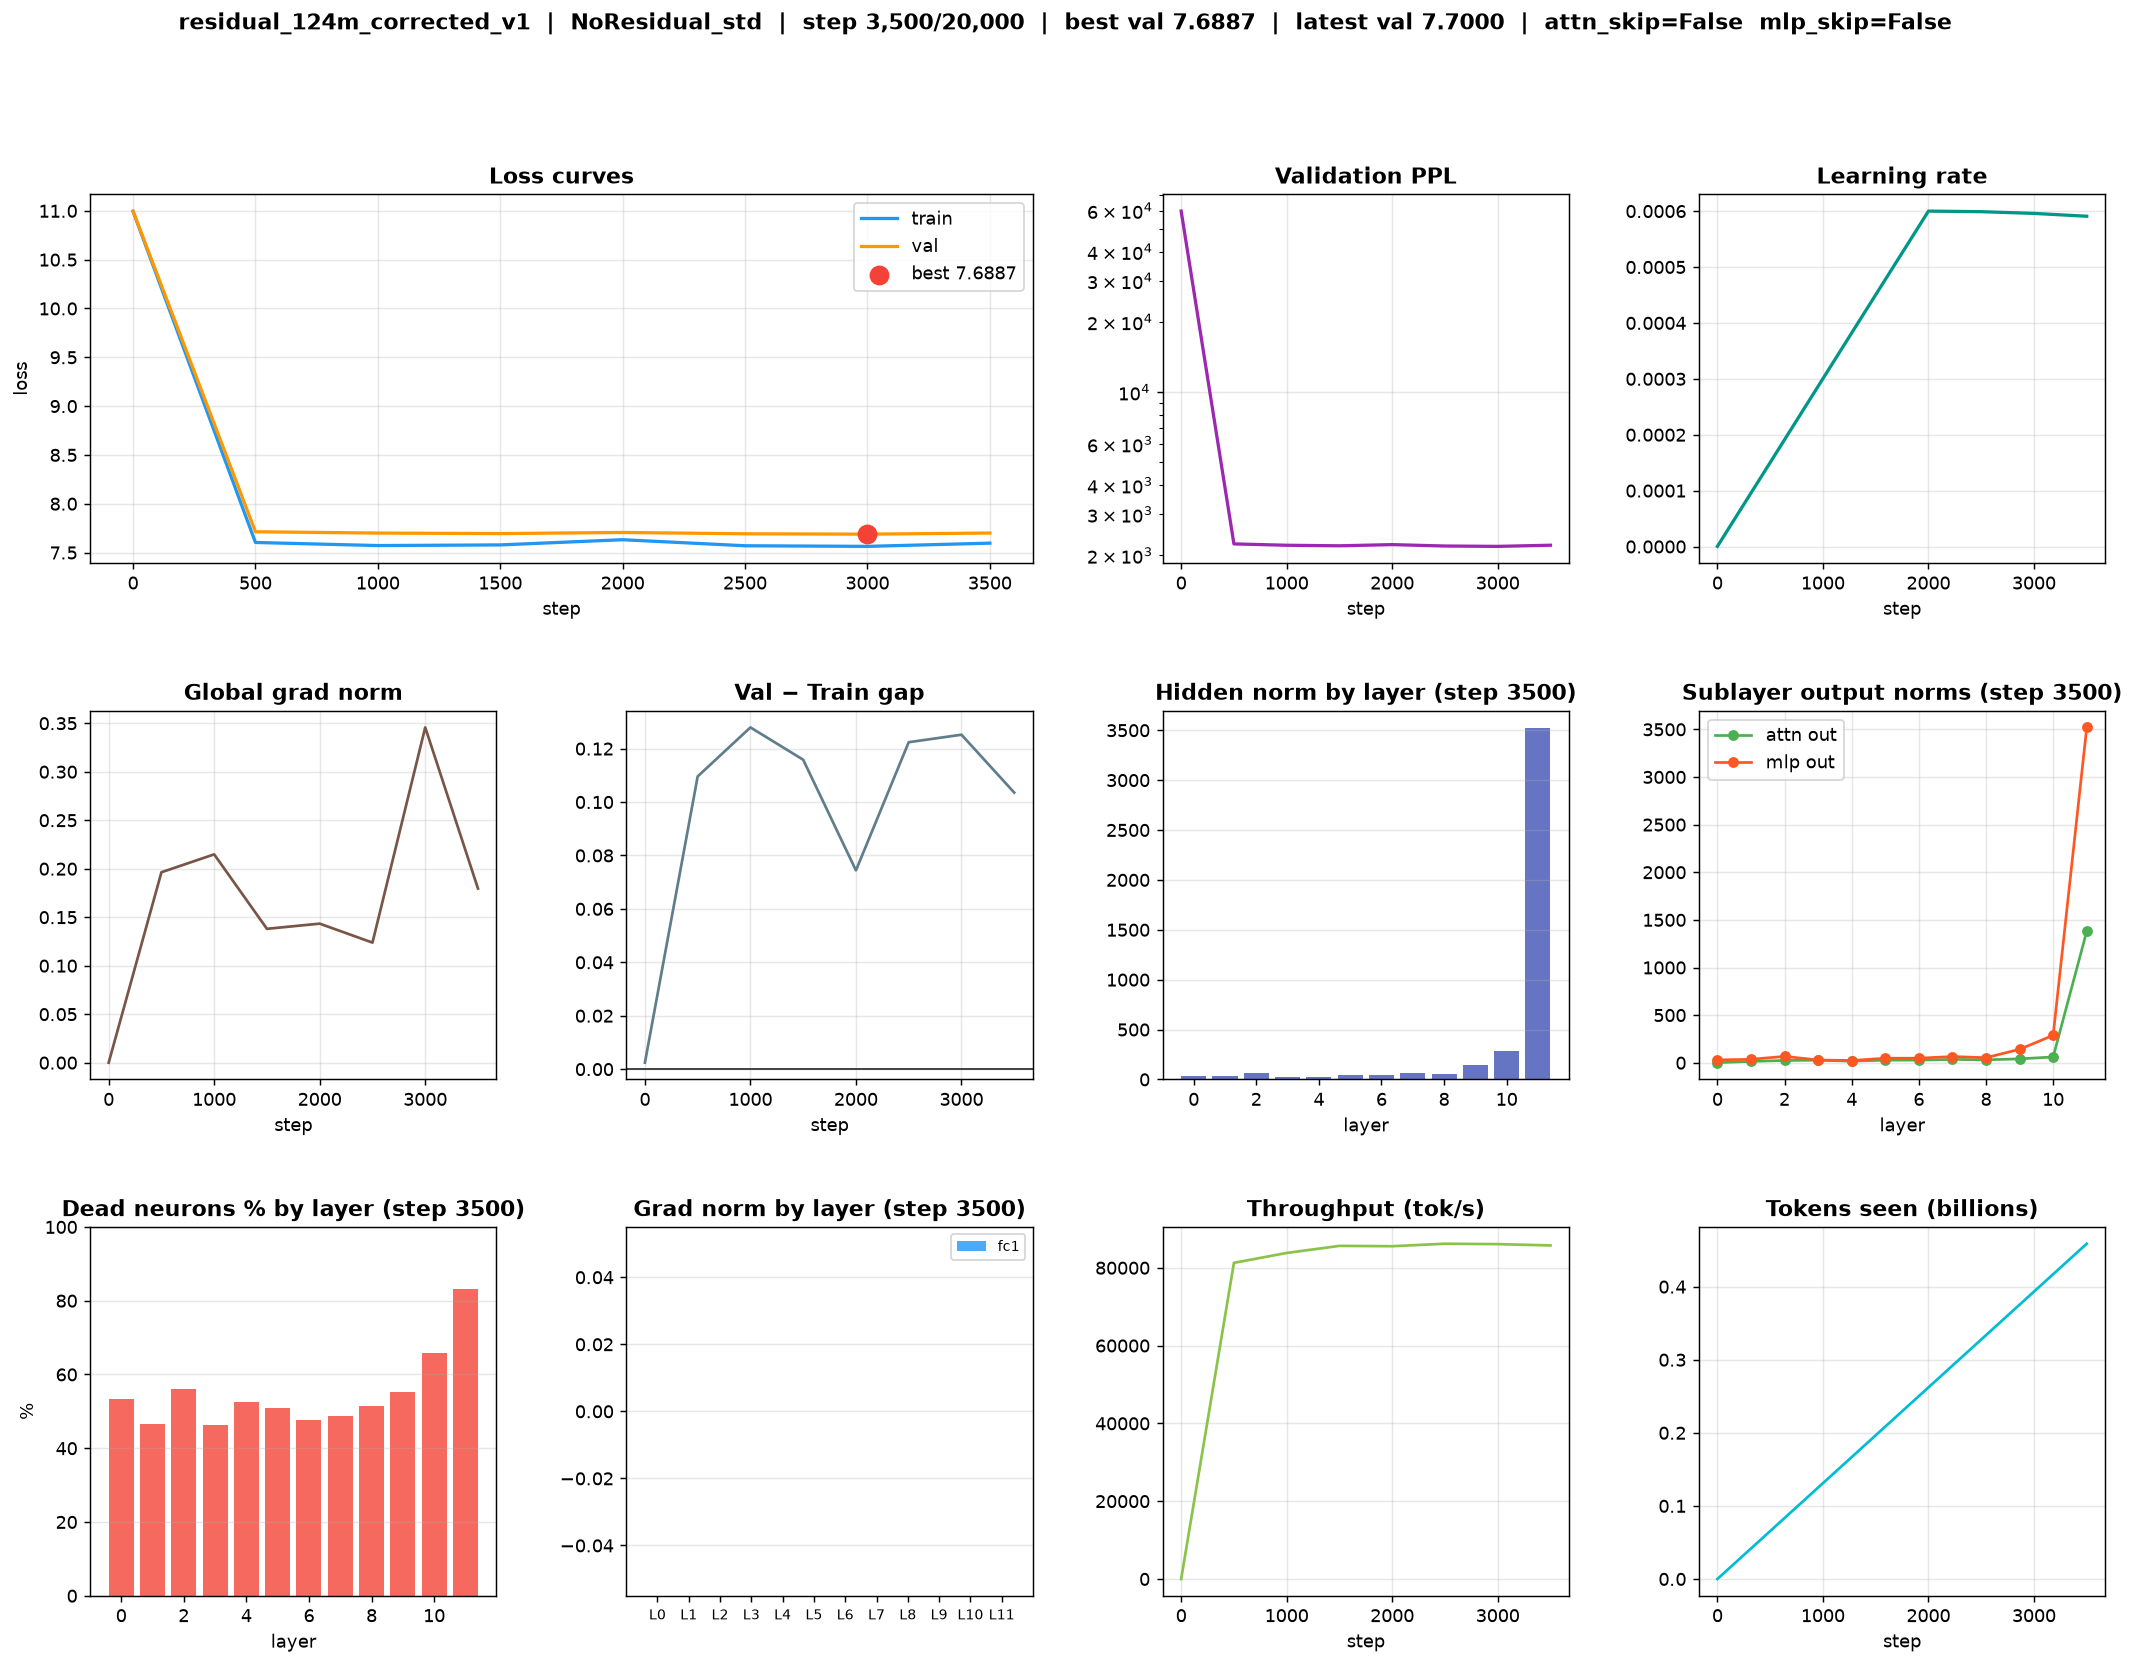

,step,train_loss,val_loss,val_ppl,global_grad_norm,generalization_gap,tokens_seen
0,0,10.9950,10.9974,59718.4102,0.0000,0.0024,0
1,500,7.6034,7.7130,2237.3055,0.1964,0.1096,65536000
2,1000,7.5718,7.6998,2207.8321,0.2148,0.1279,131072000
3,1500,7.5786,7.6944,2195.9937,0.1380,0.1158,196608000
4,2000,7.6317,7.7061,2221.8514,0.1434,0.0744,262144000
5,2500,7.5699,7.6923,2191.3497,0.1238,0.1224,327680000
6,3000,7.5635,7.6887,2183.6209,0.3457,0.1252,393216000
7,3500,7.5965,7.7000,2208.4351,0.1796,0.1035,458752000


In [ ]:
# Cell 16 - Run experiments
# This cell automatically resumes each experiment if latest.pt exists locally or was pulled from Drive.
ALL_SUMMARIES = []
for exp in EXPERIMENTS:
    summary_path = paths_for(exp)["metadata"] / "summary.json"
    if summary_path.exists():
        existing = json.loads(summary_path.read_text())
        if existing.get("complete") and RESUME:
            print(f"Skipping completed experiment: {exp.name}")
            ALL_SUMMARIES.append(existing)
            continue
    summary = train_one_experiment(exp)
    ALL_SUMMARIES.append(summary)

summary_df = pd.DataFrame(ALL_SUMMARIES)
summary_df.to_csv(PROJECT_DIR / "all_experiment_summaries.csv", index=False)
display(summary_df)
SYNC.push_project()

In [ ]:
# Cell 17 - Aggregate results + comparison dashboard + full JSON export

import math

def load_all_histories() -> Dict[str, pd.DataFrame]:
    histories = {}
    for exp in EXPERIMENTS:
        hpath = paths_for(exp)["history_csv"]
        if hpath.exists():
            histories[exp.name] = pd.read_csv(hpath)
    return histories

histories = load_all_histories()
print(f"Loaded histories for: {list(histories.keys())}")

# ── Per-run result table ────────────────────────────────────────────────────
rows = []
for exp in EXPERIMENTS:
    if exp.name not in histories:
        print(f"  MISSING: {exp.name}")
        continue
    df = histories[exp.name]
    best_idx = int(df["val_loss"].idxmin())
    rows.append({
        "name":              exp.name,
        "seed":              exp.seed,
        "family":            exp.family,
        "attention_skip":    exp.use_attention_skip,
        "mlp_skip":          exp.use_mlp_skip,
        "attention_gain":    exp.attention_gain,
        "mlp_gain":          exp.mlp_gain,
        "best_step":         int(df.loc[best_idx, "step"]),
        "best_val_loss":     float(df.loc[best_idx, "val_loss"]),
        "best_val_ppl":      float(df.loc[best_idx, "val_ppl"]),
        "final_step":        int(df["step"].iloc[-1]),
        "final_train_loss":  float(df["train_loss"].iloc[-1]),
        "final_val_loss":    float(df["val_loss"].iloc[-1]),
        "final_val_ppl":     float(df["val_ppl"].iloc[-1]),
        "generalization_gap":float(df["generalization_gap"].iloc[-1]),
        "min_train_loss":    float(df["train_loss"].min()),
        "tokens_seen":       int(df["tokens_seen"].iloc[-1]) if "tokens_seen" in df.columns else 0,
    })

results_df = pd.DataFrame(rows).sort_values(["family", "name", "seed"])

# Save CSV + JSON
results_df.to_csv(PROJECT_DIR / "results_best_and_final.csv", index=False)
results_df.to_json(PROJECT_DIR / "results_best_and_final.json",
                   orient="records", indent=2)
print("\n── Per-run results ────────────────────────────────────────────")
display(results_df[[
    "name","attention_skip","mlp_skip",
    "best_val_loss","best_val_ppl","best_step","final_val_loss"
]])

# ── Grouped mean/std ────────────────────────────────────────────────────────
if not results_df.empty:
    agg_df = results_df.groupby(
        ["family","attention_skip","mlp_skip","mlp_gain","attention_gain"], dropna=False
    ).agg(
        n=("best_val_loss","count"),
        best_val_loss_mean=("best_val_loss","mean"),
        best_val_loss_std=("best_val_loss","std"),
        best_val_ppl_mean=("best_val_ppl","mean"),
        best_val_ppl_std=("best_val_ppl","std"),
        final_val_loss_mean=("final_val_loss","mean"),
        final_val_loss_std=("final_val_loss","std"),
    ).reset_index()

    agg_df.to_csv(PROJECT_DIR / "results_grouped_mean_std.csv", index=False)
    agg_df.to_json(PROJECT_DIR / "results_grouped_mean_std.json",
                   orient="records", indent=2)
    print("\n── Grouped mean/std ────────────────────────────────────────")
    display(agg_df)

# ── THE KEY RESULT: asymmetry check ────────────────────────────────────────
print("\n" + "="*60)
print("KEY RESULT: 124M ASYMMETRY CHECK")
print("="*60)
for name in ["FullResidual_std","AttnOnly_std","FFNOnly_std","NoResidual_std"]:
    row = results_df[results_df["name"] == name]
    if row.empty:
        print(f"  {name:<22}: NOT YET RUN")
        continue
    bv = float(row["best_val_loss"])
    fr_row = results_df[results_df["name"] == "FullResidual_std"]
    fr = float(fr_row["best_val_loss"]) if not fr_row.empty else None
    ratio = f"{bv/fr:.2f}x" if fr else "—"
    converges = " CONVERGES" if bv < 5.0 else (" COLLAPSES" if bv > 6.5 else "  PARTIAL")
    print(f"  {name:<22}: best_val={bv:.4f}  ratio={ratio:<6}  {converges}")

# ── results_summary.json ────────────────────────────────────────────────────
summary = {
    "project_id":     PROJECT_ID,
    "model_preset":   MODEL_PRESET,
    "dataset_preset": DATASET_PRESET,
    "run_plan":       RUN_PLAN,
    "model_params":   "124.4M",
    "max_iters":      TRAINING.max_iters,
    "eval_interval":  TRAINING.eval_interval,
    "results":        rows,
    "aggregate":      agg_df.to_dict(orient="records") if not results_df.empty else [],
}
atomic_text_write(PROJECT_DIR / "results_summary.json",
                  json.dumps(summary, indent=2))
print("\nresults_summary.json saved")

# ── all_experiment_summaries.csv ────────────────────────────────────────────
all_rows = []
for exp in EXPERIMENTS:
    p     = paths_for(exp)
    smeta = p["metadata"] / "summary.json"
    if smeta.exists():
        s = json.loads(smeta.read_text())
        all_rows.append({
            "name":           exp.name,
            "seed":           exp.seed,
            "family":         exp.family,
            "attention_skip": exp.use_attention_skip,
            "mlp_skip":       exp.use_mlp_skip,
            "best_val_loss":  s.get("best_val_loss"),
            "best_step":      s.get("best_step"),
            "final_val_loss": s.get("final_val_loss"),
            "complete":       s.get("complete", False),
        })

if all_rows:
    pd.DataFrame(all_rows).to_csv(PROJECT_DIR / "all_experiment_summaries.csv", index=False)
    print("all_experiment_summaries.csv saved")

# ── Comparison dashboard ────────────────────────────────────────────────────
make_comparison_dashboard(histories, PROJECT_DIR / "figure_comparison_dashboard.png")

# ── Individual best val bar chart ───────────────────────────────────────────
if rows:
    CONFIG_COLORS = {
        "FullResidual_std": "#1565C0",
        "AttnOnly_std":     "#2E7D32",
        "FFNOnly_std":      "#C62828",
        "NoResidual_std":   "#616161",
    }
    fig, ax = plt.subplots(figsize=(10, 6))
    names  = [r["name"] for r in rows]
    bests  = [r["best_val_loss"] for r in rows]
    colors = [CONFIG_COLORS.get(n, "#888888") for n in names]
    bars   = ax.bar(range(len(names)), bests, color=colors, width=0.6, edgecolor="white", zorder=3)
    for bar, v in zip(bars, bests):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace("_std","") for n in names], fontsize=11)
    ax.set_ylabel("Best validation loss", fontsize=12)
    ax.set_title(f"ResidualGPT 124M · OpenWebText\nBest Validation Loss by Configuration",
                 fontsize=13, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    fig.savefig(PROJECT_DIR / "figure_best_val_bar.png", dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

# ── Val loss curves ─────────────────────────────────────────────────────────
if histories:
    fig, ax = plt.subplots(figsize=(12, 6))
    for name, df in histories.items():
        col = CONFIG_COLORS.get(name, "#333333")
        ax.plot(df["step"], df["val_loss"], lw=2.0, label=name, color=col,
                marker="o", ms=3)
    ax.set_xlabel("step", fontsize=12)
    ax.set_ylabel("validation loss", fontsize=12)
    ax.set_title("ResidualGPT 124M · OpenWebText\nValidation Loss Curves",
                 fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    fig.savefig(PROJECT_DIR / "figure_val_loss_curves.png", dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

SYNC.push_project()
print("\n Cell 17 complete — all results saved and synced to GDrive")


In [ ]:
# Cell 18 - Export pack for GitHub / paper

EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for filename in [
    "environment.json",
    "experiment_plan.json",
    "experiment_plan.csv",
    "all_experiment_summaries.csv",
    "results_best_and_final.csv",
    "results_best_and_final.json",
    "results_grouped_mean_std.csv",
    "results_grouped_mean_std.json",
    "results_summary.json",
    "figure_best_val_bar.png",
    "figure_val_loss_curves.png",
    "figure_comparison_dashboard.png",
]:
    src = PROJECT_DIR / filename
    if src.exists():
        shutil.copy2(src, EXPORT_DIR / filename)

# Copy final dashboards
dash_root = EXPORT_DIR / "dashboards"
dash_root.mkdir(exist_ok=True)
for exp in EXPERIMENTS:
    fig_path = paths_for(exp)["figures"] / "final_dashboard.png"
    if not fig_path.exists():
        fig_path = paths_for(exp)["figures"] / "dashboard_latest.png"
    if fig_path.exists():
        shutil.copy2(fig_path, dash_root / f"{exp.name}_dashboard.png")

readme = f"""
# ResidualGPT 124M Corrected Run

**Project ID:** `{PROJECT_ID}`
**Model:** 124M parameters (12 layers, d=768, 12 heads)
**Dataset:** OpenWebText (BPE tokenization, vocab=50,257)
**Scale:** 20,000 training steps, batch_size=16, grad_accum=8
**Implementation:** ResidualGPT (corrected — fixed val batches, weight tying)

## Purpose

Verify the 10M residual asymmetry result at 124M scale.
The 10M result (ResidualGPT): AttnOnly converges to 1.573±0.006, FFNOnly collapses to 3.349±0.001.
The 124M nanoGPT result: both AttnOnly and FFNOnly collapse to ~7.4.
This run tests whether the 10M AttnOnly convergence holds at 124M in the corrected implementation.

## Key question

Does AttnOnly_std converge (best val < 5.0) or collapse (best val > 7.0)?

## Files

- `results_best_and_final.json` — per-run best and final metrics
- `results_grouped_mean_std.json` — grouped aggregates
- `results_summary.json` — single summary payload
- `figure_best_val_bar.png` — best val loss comparison
- `figure_val_loss_curves.png` — val loss curves all configs
- `figure_comparison_dashboard.png` — cross-run comparison
- `dashboards/` — per-run training dashboards
- `environment.json` — hardware and package metadata
- `experiment_plan.json` — exact experiment specifications

## GDrive path

`gdrive:ResidualInitRuns/{PROJECT_ID}/`

## Resume

Keep PROJECT_ID = "{PROJECT_ID}" and REMOTE_ROOT stable.
On a new instance: run cells 1–16, the sync manager pulls from Drive and resumes.
""".strip()

(EXPORT_DIR / "README.md").write_text(readme, encoding="utf-8")

archive_base = PROJECT_DIR / "github_export"
zip_path = shutil.make_archive(str(archive_base), "zip", root_dir=str(EXPORT_DIR))
print(f"Export folder : {EXPORT_DIR}")
print(f"Zip archive   : {zip_path}")
SYNC.push_project()
print("\n✅ Export complete and synced to GDrive")
